In [1]:
pwd()

"/home/felipe/felipe/trabuco/Polyhedron"

In [1]:
using Pkg
Pkg.activate(".")
#Pkg.add(["LinearAlgebra", "DelimitedFiles", "JuMP", "HiGHS", "NEOSServer", "Polyhedra", "CDDLib", "Plots"])
Pkg.instantiate()
include("Polyhedron.jl")
using .Poly

  Activating project at `~/felipe/trabuco/Polyhedron`
project at `~/felipe/trabuco/Polyhedron`
┌ Warning: Make sure you comply with the NEOS terms of use: http://www.neos-server.org/neos/termofuse.html
└ @ NEOSServer /home/felipe/.julia/packages/NEOSServer/2P7PD/src/NEOSServer.jl:14
┌ Warning: Make sure you comply with the NEOS terms of use: http://www.neos-server.org/neos/termofuse.html
└ @ NEOSServer /home/felipe/.julia/packages/NEOSServer/2P7PD/src/NEOSServer.jl:14


In [2]:
A = [0.9666 0;
    0.0328 0.9666] 
B = [0.1980;
    0.0033;;]

C = [0 1]

T = 0.5

delta = 0.5

A_exp = hcat(A, [0 0; 0 0])
A_exp = vcat(A_exp, [0 -T 1 T; 0 0 0 delta])

B_exp = vcat(B, [0;0])

E_exp = vcat(zeros(3), [1-delta])

Sx = [1/15 0
      0 1/15;
     -1/15 0;
      0 -1/15;]
Sv = [1/300;
      -1/300;]

Sw = [1/50;
      -1/50;]

Sx = vcat(Sx, zeros(4, 2))
Sv = vcat(vcat(zeros(4, 1), Sv) , zeros(2, 1))
Sw = vcat(zeros(6, 1), Sw)

S = hcat(hcat(Sx, Sv), Sw)

# Fr para a referência
R = [1/15;
      -1/15;;]
d = 2

2

tentando achar um poliedro p-invariante w.t. x(k+1) = Ax(k) BGx(k-d) + Er(k) 

In [3]:
result = Poly.finding_L_pinvariant_segref_delay2(A_exp, B_exp, S, d; lf=16, tmax=1200.0)

Job 18691955 dispatched
password: qgDfYIdO
---------- Begin Solver Output -----------
Condor submit: 'neos.submit'
Condor submit: 'watchdog.submit'

Job submitted to NEOS HTCondor pool.

Job submitted to NEOS HTCondor pool.

OTHER_LIMITOTHER_LIMIT

Dict{String, Any} with 11 entries:
  "Z"      => [0.307583 0.308666 … 0.310515 0.308215; 3.24701e-6 3.247e-6 … 0.1…
  "T"      => [0.0149296 0.0101363 … 0.014895 0.014912; 3.23322e-5 1.40112e-5 ……
  "L"      => [0.0153657 0.0146786 … 0.015365 0.0153649; 6.51098e-8 5.35069e-7 …
  "M"      => [0.00768285 0.00735759 … 0.00768251 0.00768248; 3.24786e-8 1.4063…
  "N"      => [0.00768284 0.00735543 … 0.00768251 0.00768248; 3.24283e-8 1.7544…
  "igamma" => 2.7846
  "lambda" => 0.999
  "H"      => [0.0153692 0.015135 … 0.0153702 0.0153695; 6.51188e-8 0.947959 … …
  "G"      => [-0.331124 -0.340194 0.00701166 0.00731928]
  "K"      => [-0.0529869 -0.0288444 0.00127148 0.000541657; -0.00449397 -0.010…
  "F"      => [-0.000238446 -9.28192e-5 -4.4468e-6 4.59916e-5; -0.0424333 -0.12…

In [7]:
# F = [0.0045937658905031405	0.005265935698278693	-0.0001831912068949287	0.0004235196671852721;
# -0.387546504750536	-0.5399597613753225	0.022916989629361034	5.2632483231774e-7;
# -0.0003813758632262442	-0.0005314200553276358	-0.003312302393793111	-3.1723577713463345e-6;
# 0.06687825912156184	0.09209951632824671	-0.003974728008497188	-0.0022411340266554804;
# 0.0015400828233313225	0.005945863335077955	-0.0001727609426690916	-0.00029480032254931474;
# 0.0899212063463028	0.12540839471364143	-0.005429350220208652	-0.0015275663666760966;
# -0.0012763052664025512	-0.015550653533011688	0.0009804315309843705	-6.576693781396904e-5;
# 0.0394645369173265	0.05390327965869691	-0.002151623774364355	-0.0032921537449794166;
# 0.015114977636432535	0.20710588850530953	-0.006722848765565407	-4.175688606721699e-6;
# -0.0013851902403216466	-0.025628212657826048	0.0008245513614762111	-0.0002658240934445424;
# -4.609924899362604e-7	9.888944152307318e-6	9.914638714003359e-6	0.06532529983823963;
# -0.005905957120934324	0.016152942890900142	-0.00044524206790640114	-6.23065703604069e-5]

# G = [-1.9834694776984396	-2.7620086000838957	0.1188859457437794	0.14593568267190546]

using LinearAlgebra
F = result["F"]
G = result["G"]

matrix_inv = inv(I(size(A_exp, 1)) - A_exp - B_exp*G)
result_matrix = F * matrix_inv * E_exp

a = 1/0.133842839

# eig = eigvals(I(size(A_exp, 1)) - A_exp - B_exp*G)



7.471449406419121

In [4]:
using LinearAlgebra

println("=== Verificação das Restrições (Versão NÃO Simétrica) ===\n")

# Extrair matrizes da versão não simétrica
F = result["F"]
G = result["G"]
H = result["H"]
L = result["L"]
M = result["M"]
N = result["N"]
P = result["P"]
T = result["T"]
Z = result["Z"]
K = result["K"]

println("=== Verificação das Restrições de Igualdade ===\n")

# H*F == F*(A+K)
constraint_H = abs.(H*F - F*(A_exp+K))
max_H = maximum(constraint_H)
println("H*F == F*(A+K)")
println("Max error: $max_H\n")

# L*F == F*(B*G - K)
constraint_L = abs.(L*F - F*(B_exp*G - K))
max_L = maximum(constraint_L)
println("L*F == F*(B*G - K)")
println("Max error: $max_L\n")

# M*F == -F*K*(A-I(size(A_exp,1)))
constraint_M = abs.(M*F - (-F*K*(A_exp-I(size(A_exp,1)))))
max_M = maximum(constraint_M)
println("M*F == -F*K*(A-I)")
println("Max error: $max_M\n")

# N*F == -F*K*B*G
constraint_N = abs.(N*F - (-F*K*B_exp*G))
max_N = maximum(constraint_N)
println("N*F == -F*K*B*G")
println("Max error: $max_N\n")

# P*R == F*E
constraint_P = abs.(P*R - F*E_exp)
max_P = maximum(constraint_P)
println("P*R == F*E")
println("Max error: $max_P\n")

# T*F == S
constraint_T = abs.(T*F - S)
max_T = maximum(constraint_T)
println("T*F == S")
println("Max error: $max_T\n")

# # J*F == I(n)
# constraint_J = abs.(J*F - I(size(A_exp,1)))
# max_J = maximum(constraint_J)
# println("J*F == I(n)")
# println("Max error: $max_J\n")

# Z*S == F
constraint_Z = abs.(Z*S - F)
max_Z = maximum(constraint_Z)
println("Z*S == F")
println("Max error: $max_Z\n")

println("=== Verificação das Restrições de Desigualdade ===\n")

# Z*ones_s <= ones_f*igamma
ones_f = ones(size(F, 1))
ones_s = ones(size(S, 1))
constraint_Z_ineq = Z*ones_s
max_Z_ineq = maximum(constraint_Z_ineq)
println("Z*ones_s <= ones_f*igamma")
println("Max value: $max_Z_ineq")
println("All <= 1.0? $(all(constraint_Z_ineq .<= 1.0 .+ 1e-5))\n")

# T*ones_f <= ones_s
constraint_T_ineq = T*ones_f
max_T_ineq = maximum(constraint_T_ineq)
println("T*ones_f <= ones_s")
println("Max value: $max_T_ineq")
println("All <= 1.0? $(all(constraint_T_ineq .<= ones_s .+ 1e-5))\n")

# (H + L + d*(M + N))*ones_f + P*ones_r <= lambda*ones_f
ones_r = ones(size(R, 1))
lambda = 0.99
constraint_lambda = (H + L + d*(M + N))*ones_f + P*ones_r
max_lambda_constraint = maximum(constraint_lambda)
println("(H + L + d*(M + N))*ones_f + P*ones_r <= lambda*ones_f")
println("Max value: $max_lambda_constraint")
println("Lambda: $lambda")
println("All <= lambda? $(all(constraint_lambda .<= lambda .+ 1e-5))\n")

=== Verificação das Restrições (Versão NÃO Simétrica) ===

=== Verificação das Restrições de Igualdade ===

H*F == F*(A+K)
Max error: 5.8888253941904826e-5

L*F == F*(B*G - K)
Max error: 5.9076502484365736e-5

M*F == -F*K*(A-I)
Max error: 5.8888253941904826e-5

L*F == F*(B*G - K)
Max error: 5.9076502484365736e-5

M*F == -F*K*(A-I)
Max error: 4.296194767075417e-6

N*F == -F*K*B*G
Max error: 1.4476562875105905e-5

P*R == F*E
Max error: 4.296194767075417e-6

N*F == -F*K*B*G
Max error: 1.4476562875105905e-5

P*R == F*E
Max error: 1.6112925824345082e-7

T*F == S
Max error: 2.498673288661886e-7

Z*S == F
Max error: 1.8041231269333435e-11

=== Verificação das Restrições de Desigualdade ===

Z*ones_s <= ones_f*igamma
Max value: 1200.6201555519187
All <= 1.0? false

Max error: 1.6112925824345082e-7

T*F == S
Max error: 2.498673288661886e-7

Z*S == F
Max error: 1.8041231269333435e-11

=== Verificação das Restrições de Desigualdade ===

Z*ones_s <= ones_f*igamma
Max value: 1200.6201555519187
All 

In [8]:
using LinearAlgebra

# Verificar restrições de igualdade e desigualdade
F = result["F"]
G = result["G"]
H_diff = result["H_diff"]
L_diff = result["L_diff"]
M_diff = result["M_diff"]
N_diff = result["N_diff"]
P_diff = result["P_diff"]
T_diff = result["T_diff"]
Z_diff = result["Z_diff"]

H_sum = result["H_sum"]
L_sum = result["L_sum"]
M_sum = result["M_sum"]
N_sum = result["N_sum"]
P_sum = result["P_sum"]
T_sum = result["T_sum"]
Z_sum = result["Z_sum"]

K = result["K"]
J = result["J"]

println("=== Verificação das Restrições de Igualdade ===\n")

# H*F == F*(A+K)
constraint_H = abs.(H_diff*F - F*(A_exp+K))
max_H = maximum(constraint_H)
println("H*F == F*(A+K)")
println("Max error: $max_H\n")

# L*F == F*(B*G - K)
constraint_L = abs.(L_diff*F - F*(B_exp*G - K))
max_L = maximum(constraint_L)
println("L*F == F*(B*G - K)")
println("Max error: $max_L\n")

# M*F == -F*K*(A-I(size(A_exp,1)))
constraint_M = abs.(M_diff*F - (-F*K*(A_exp-I(size(A_exp,1)))))
max_M = maximum(constraint_M)
println("M*F == -F*K*(A-I)")
println("Max error: $max_M\n")

# N*F == -F*K*B*G
constraint_N = abs.(N_diff*F - (-F*K*B_exp*G))
max_N = maximum(constraint_N)
println("N*F == -F*K*B*G")
println("Max error: $max_N\n")

# P*R == F*E
constraint_P = abs.(P_diff*R - F*E_exp)
max_P = maximum(constraint_P)
println("P*R == F*E")
println("Max error: $max_P\n")

# T*F == S
constraint_T = abs.(T_diff*F - S)
max_T = maximum(constraint_T)
println("T*F == S")
println("Max error: $max_T\n")

# J*F == I(n)
constraint_J = abs.(J*F - I(size(A_exp,1)))
max_J = maximum(constraint_J)
println("J*F == I(n)")
println("Max error: $max_J\n")

# Z*S == F
constraint_Z = abs.(Z_diff*S - F)
max_Z = maximum(constraint_Z)
println("Z*S == F")
println("Max error: $max_Z\n")

println("=== Verificação das Restrições de Desigualdade ===\n")

# Z*ones_s <= ones_f*igamma (aqui igamma = 1 no mínimo)
ones_f = ones(size(F, 1))
ones_s = ones(size(S, 1))
constraint_Z_ineq = Z_sum*ones_s
max_Z_ineq = maximum(constraint_Z_ineq)
println("(Z_p + Z_m)*ones_s <= ones_f*igamma")
println("Max value: $max_Z_ineq")
println("All <= 1.0? $(all(constraint_Z_ineq .<= 1.0 .+ 1e-5))\n")

# T*ones_f <= ones_s
constraint_T_ineq = T_sum*ones_f
max_T_ineq = maximum(constraint_T_ineq)
println("(T_p + T_m)*ones_f <= ones_s")
println("Max value: $max_T_ineq")
println("All <= 1.0? $(all(constraint_T_ineq .<= ones_s .+ 1e-5))\n")

# ((Hp + Hm) + (Lp + Lm) + d*((Mp + Mm) + (Np + Nm)))*ones_f + (Pp + Pm)*ones_r <= lambda*ones_f
d = 1
ones_r = ones(size(R, 1))
lambda = 0.99
constraint_lambda = (H_sum + L_sum + d*(M_sum + N_sum))*ones_f + P_sum*ones_r
max_lambda_constraint = maximum(constraint_lambda)
println("((H_p+H_m) + (L_p+L_m) + d*((M_p+M_m) + (N_p+N_m)))*ones_f + (P_p+P_m)*ones_r <= lambda*ones_f")
println("Max value: $max_lambda_constraint")
println("Lambda: $lambda")
println("All <= lambda? $(all(constraint_lambda .<= lambda .+ 1e-5))\n")

KeyError: KeyError: key "H_diff" not found

In [6]:

F = vcat(F, -F)

40×4 Matrix{Float64}:
 -0.00125667  -0.0509978   0.000114972   0.0632194
 -0.226831     0.990072   -0.00166571    0.000542807
 -1.59936     -1.96983     0.00780644    0.00776204
  0.05135     -0.299593    0.000533936   0.000108385
  0.0445095   -0.137468    0.000161317  -0.000212073
  0.226277    -1.4417      0.00267217    6.44482e-7
  1.6006       1.9717     -0.0078085    -0.00775859
  0.0646919   -0.343898    0.000608822  -6.98432e-5
 -0.226627     1.44372    -0.00266956   -5.0255e-7
  0.0257125   -0.106596    0.000149062  -4.43238e-5
  ⋮                                     
  0.13341     -0.558042    0.000869028  -0.00027943
 -0.0100114   -0.0741707   0.000172136   0.000149083
 -1.00398e-7  -6.7783e-7   0.00333336    1.69538e-7
 -0.00211451   0.119712   -0.000247864  -0.000175948
  0.196415    -1.27525     0.0023681    -0.000438572
 -0.00136046  -0.0511241   0.000115263   0.0632269
  0.00313923   0.0173423  -5.17877e-5   -0.000355083
 -0.0358305    0.2707     -0.000514302  -9.4403e-

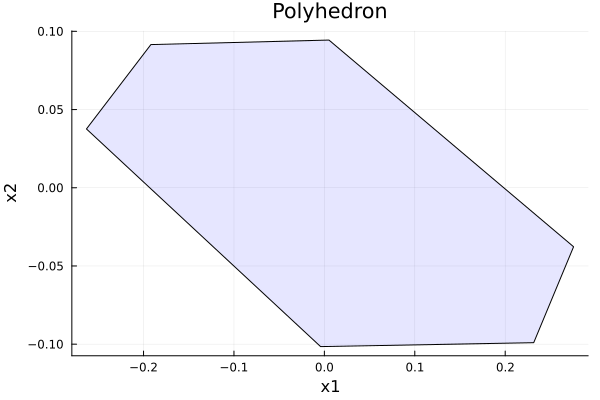

In [5]:
T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

simulando trajetórias

In [10]:
G = result["G"]

1×4 Matrix{Float64}:
 -1.70198  -2.4401  0.101522  0.155023

testando se o sistema em malha fechada é estável (para d = 0)

In [9]:
using LinearAlgebra

eigvals(A_exp + B_exp*G)

4-element Vector{Float64}:
 0.5
 0.8520480039183714
 0.928083649583179
 0.9988913505907233

simulando a trajetória 

In [10]:
using  Polyhedra, CDDLib, Base.Iterators

function get_extVert_tuple(init_cond_F, init_cond_w, i, n)
    hrep_ic = hrep(init_cond_F, init_cond_w)
    P = vrep(polyhedron(hrep_ic, CDDLib.Library()))

    ext_vertices = collect(points(P))
    vertice_alvo = ext_vertices[i]

    ext_vertices_tuple = Tuple[]

    for i in 1:n:length(vertice_alvo)
        estado = vertice_alvo[i : i + n - 1]
        push!(ext_vertices_tuple, Tuple(estado))
    end

    return ext_vertices_tuple
end

function trajectory_segref_delay(x0, A, BG, E, r, passos, d; varying=false, reverse=true)
    # Como o vetor vem na forma [x[k]...x[k-d]] para plotar a trajetória
    # é melhor que esteja na ordem cronológica [x[k-d]...x[k]]
    x0_traj = copy(x0)

    if reverse
        reverse!(x0_traj)
    end
    
    for i in 1:passos
        x_atual = collect(x0_traj[end])
        x_atrasado = collect(x0_traj[end - d])
        x_novo = A * x_atual + BG * x_atrasado + E * r[i]

        push!(x0_traj, Tuple(x_novo))   
    end

    return x0_traj[d+1:end]
end

trajectory_segref_delay (generic function with 1 method)

In [26]:
w = ones(size(F, 1))
nx = size(A_exp, 1)

passos = 100
r = ones(passos) # x2 ir para 1 

BG = B_exp * G

init_cond_F, init_cond_w = Poly.admissable_initCond(A_exp, BG, F, d, w; fixed_d=true)
ext_vertices_tuple = get_extVert_tuple(init_cond_F, init_cond_w, 2, nx)
traj1 = trajectory_segref_delay(ext_vertices_tuple, A_exp, BG, E_exp, r, passos, d; reverse=true)


101-element Vector{Tuple}:
 (-9.174054608325122, -4.0600243935245475, -294.43721346080395, -15.262767162022763)
 (-10.22564842371198, -4.247962023922307, -300.03858484505304, -7.131383581011382)
 (-11.432778534865442, -4.467292473429479, -301.48029562359756, -3.065691790505691)
 (-11.980716895504193, -4.708576593488909, -300.77949528213566, -1.0328458952528454)
 (-11.832792436957057, -4.948481507534963, -298.9416299330176, -0.016422947626422713)
 (-11.267429532408897, -5.168482023162923, -296.47560065306334, 0.49178852618678864)
 (-10.575212933083195, -5.360161671369905, -293.6454653783885, 0.7458942630933943)
 (-9.935102446951472, -5.523217616181833, -290.5924374111569, 0.8729471315466972)
 (-9.409436255944751, -5.661382945240059, -287.3943550372926, 0.9364735657733486)
 (-8.988006572741298, -5.779136355526448, -284.0954267817859, 0.9682367828866743)
 ⋮
 (-0.6700018875626954, -2.0083154269507224, -58.883794144828116, 1.0)
 (-0.6438165057080054, -1.963150298289123, -57.37963643135276, 

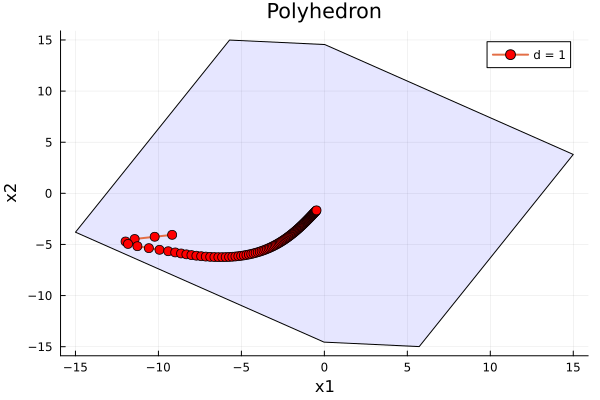

In [27]:
using Plots

T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

x1 = [p[1] for p in traj1]
x2 = [p[2] for p in traj1]
v = [p[3] for p in traj1]
w = [p[4] for p in traj1]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 1",
     xlabel = "x1",
     ylabel = "x2")
     


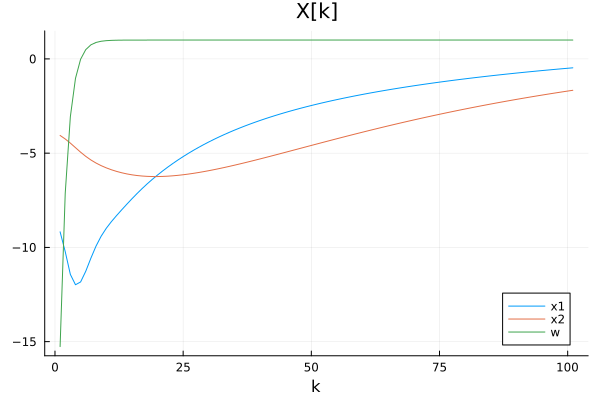

In [28]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

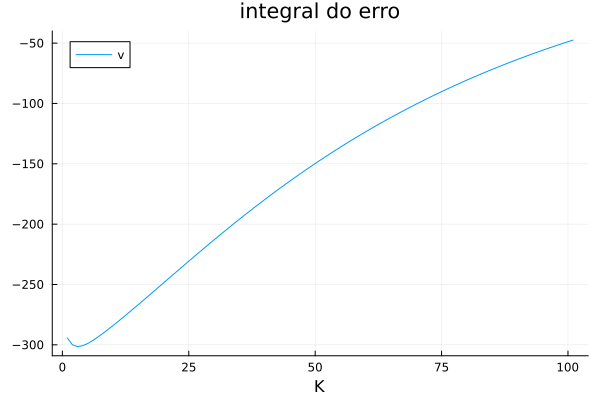

In [29]:
plot(v,
    label="v",
    xlabel="K",
    title="integral do erro")

simulando para outras referências

In [47]:
passos = 500
r = ones(passos)*8.2
traj5 = trajectory_segref_delay(ext_vertices_tuple, A_exp, BG, E_exp, r, passos, d; reverse=true)

501-element Vector{Tuple}:
 (-9.174054608325122, -4.0600243935245475, -294.43721346080395, -15.262767162022763)
 (-10.22564842371198, -4.247962023922307, -300.03858484505304, -3.531383581011382)
 (-11.432778534865442, -4.467292473429479, -299.6802956235976, 2.3343082094943086)
 (-11.876693940895658, -4.706842877578767, -296.2794952821357, 5.267154104747154)
 (-11.533838466056563, -4.940086988442127, -291.29249679097273, 6.733577052373576)
 (-10.73229382486643, -5.146459410774418, -285.4556647705649, 7.466788526186788)
 (-9.80484964006293, -5.3171038110592885, -279.1490408020843, 7.8333942630933935)
 (-8.951727837933355, -5.452350948228114, -272.57379176500797, 8.016697131546696)
 (-8.238963595409114, -5.556962824095888, -265.8392677251206, 8.108348565773348)
 (-7.651011848199432, -5.63638543231512, -259.006612030186, 8.154174282886673)
 ⋮
 (8.20435543553508, 8.18851887246262, 328.6985349012922, 8.2)
 (8.204451429040253, 8.18869389149212, 328.7042754650609, 8.2)
 (8.204545959214402, 8.1

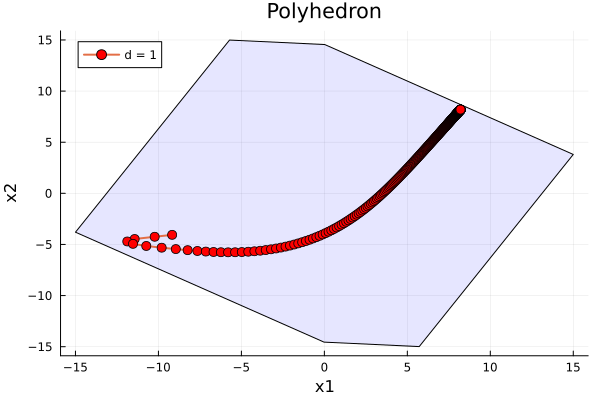

In [48]:
Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

x1 = [p[1] for p in traj5]
x2 = [p[2] for p in traj5]
v = [p[3] for p in traj5]
w = [p[4] for p in traj5]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 1",
     xlabel = "x1",
     ylabel = "x2")

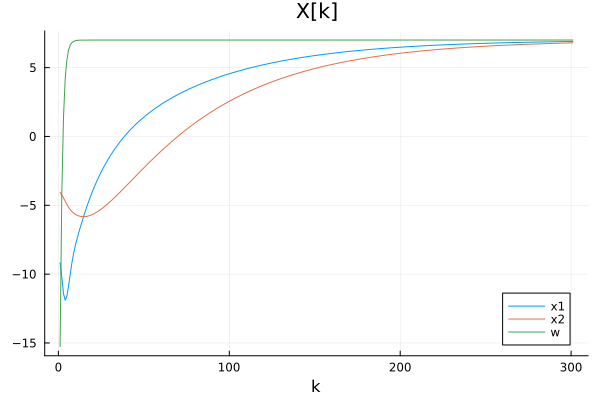

In [34]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

alterando a referência no meio da simulação 

In [49]:
passos = 500
r = ones(passos)*-8.2
traj5_2 = trajectory_segref_delay(traj5, A_exp, BG, E_exp, r, passos, d; reverse=false)

1000-element Vector{Tuple}:
 (-10.22564842371198, -4.247962023922307, -300.03858484505304, -3.531383581011382)
 (-11.432778534865442, -4.467292473429479, -299.6802956235976, 2.3343082094943086)
 (-11.876693940895658, -4.706842877578767, -296.2794952821357, 5.267154104747154)
 (-11.533838466056563, -4.940086988442127, -291.29249679097273, 6.733577052373576)
 (-10.73229382486643, -5.146459410774418, -285.4556647705649, 7.466788526186788)
 (-9.80484964006293, -5.3171038110592885, -279.1490408020843, 7.8333942630933935)
 (-8.951727837933355, -5.452350948228114, -272.57379176500797, 8.016697131546696)
 (-8.238963595409114, -5.556962824095888, -265.8392677251206, 8.108348565773348)
 (-7.651011848199432, -5.63638543231512, -259.006612030186, 8.154174282886673)
 (-7.144234454814186, -5.694896120869147, -252.1113321725851, 8.177087141443337)
 ⋮
 (-8.204410294740168, -8.188618893863186, -328.7018155687135, -8.2)
 (-8.20450545196817, -8.188792388160174, -328.70750612178193, -8.2)
 (-8.20459915861

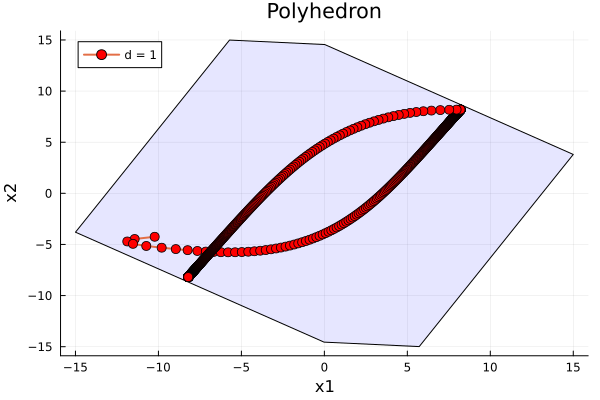

In [50]:
Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

x1 = [p[1] for p in traj5_2]
x2 = [p[2] for p in traj5_2]
v = [p[3] for p in traj5_2]
w = [p[4] for p in traj5_2]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 1",
     xlabel = "x1",
     ylabel = "x2")

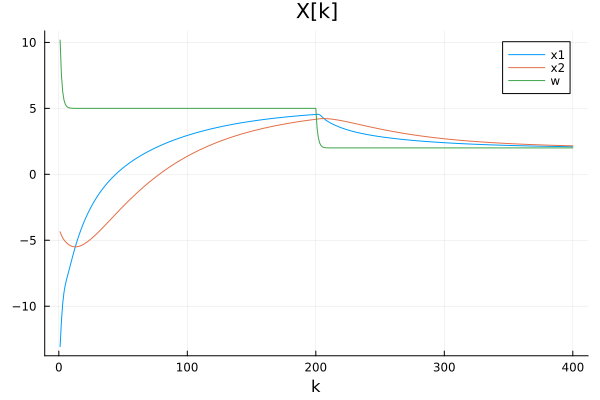

In [24]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

In [25]:
passos = 150
r = ones(passos)*10
traj5_10 = trajectory_segref_delay(traj5, A_exp, BG, E_exp, r, passos, d; reverse=false)

350-element Vector{Tuple}:
 (-13.061926201774588, -4.358371389373173, -290.441460499891, 10.17784160491354)
 (-11.187644570177829, -4.617266076112024, -283.1733540027476, 7.58892080245677)
 (-9.832359002173897, -4.813643827082383, -277.0702605634632, 6.294460401228385)
 (-8.962243336454941, -4.966340917278362, -271.5162084493078, 5.647230200614192)
 (-8.40008505958371, -5.090046389586426, -266.2094228903615, 5.323615100307096)
 (-7.9843738156171185, -5.193309156745644, -261.0025921454147, 5.161807550153548)
 (-7.615483218905854, -5.280036550208087, -255.82503379196513, 5.080903775076774)
 (-7.2494172506017645, -5.351609365198039, -250.6445636293227, 5.040451887538387)
 (-6.876397369663769, -5.408465009140697, -245.4485330029545, 5.020225943769193)
 (-6.501725538737263, -5.450951442247374, -240.23418752649954, 5.010112971884597)
 ⋮
 (9.50862295329437, 9.10728563333945, 379.2098394643083, 10.0)
 (9.516038447886885, 9.12040185107451, 379.6561966476386, 10.0)
 (9.523344732662228, 9.1333255

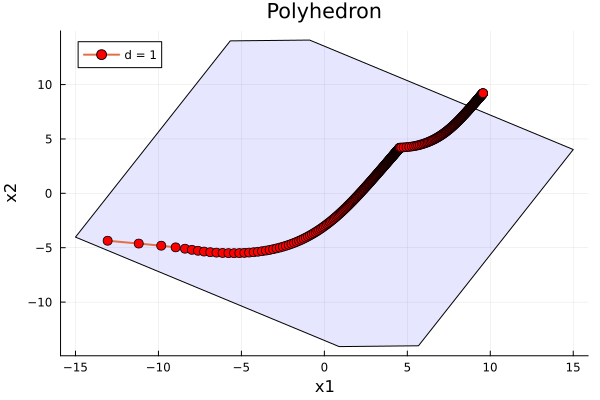

In [27]:
Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

x1 = [p[1] for p in traj5_10]
x2 = [p[2] for p in traj5_10]
v = [p[3] for p in traj5_10]
w = [p[4] for p in traj5_10]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 1",
     xlabel = "x1",
     ylabel = "x2")

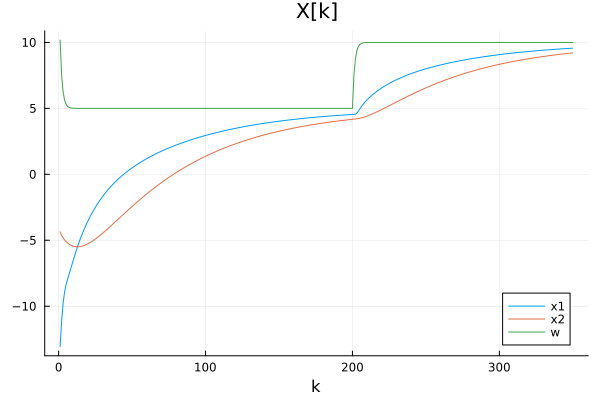

In [28]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")